<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_VisAnomReasoner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# [CELL 1 - Environment Setup]
!pip install -q torch torchvision transformers peft accelerate pillow matplotlib scipy scikit-learn

import os
import io
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoProcessor, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.ensemble import IsolationForest

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cuda


In [18]:
# [CELL 2 - Border-Free Plot Renderer & Benchmark Generator]

def generate_visanom_sample(seq_len=200, img_size=(400, 200)):
    t = np.arange(seq_len)
    base_signal = np.sin(2 * np.pi * t / 30.0) + np.random.normal(0, 0.15, size=seq_len)

    anomaly_len = np.random.randint(15, 25)
    t_start = np.random.randint(30, seq_len - anomaly_len - 30)
    t_end = t_start + anomaly_len

    anomaly_type = random.choice(["inverted_spike", "variance_shift", "level_shift"])
    signal = base_signal.copy()

    if anomaly_type == "inverted_spike":
        signal[t_start:t_end] = -3.0 * np.sin(2 * np.pi * t[t_start:t_end] / 30.0)
        desc = "inverted spike where expected peaks flip sharply to negative troughs."
    elif anomaly_type == "variance_shift":
        signal[t_start:t_end] += np.random.normal(0, 1.2, size=anomaly_len)
        desc = "sudden high-frequency variance shift with high noise amplitude."
    else:
        signal[t_start:t_end] += 2.5
        desc = "sustained positive baseline shift off the mean."

    # Render borderless image plot (1:1 spatial pixel-to-time mapping)
    fig = plt.figure(figsize=(img_size[0]/100, img_size[1]/100), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1])  # Full canvas, 0 margin
    ax.plot(t, signal, color='#1f77b4', linewidth=2.0)
    ax.set_xlim(0, seq_len)
    ax.set_ylim(-4.5, 4.5)
    ax.axis('off')  # Strip ticks and labels

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=100)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')

    rationale = (
        f"Step 1: The plot displays a sequential signal across {seq_len} time units.\n"
        f"Step 2: A structural deviation occurs between t={t_start} and t={t_end} ({desc}).\n"
        f"Step 3: Anomaly located at interval [{t_start}, {t_end}]."
    )

    norm_interval = [t_start / seq_len, t_end / seq_len]
    return img, signal, (t_start, t_end), norm_interval, rationale

# Re-initialize dataset loaders
train_dataset = VisAnomDataset(num_samples=400)
test_dataset  = VisAnomDataset(num_samples=100)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Border-free dataset generated successfully.")

Border-free dataset generated successfully.


In [19]:
# [CELL 3 - VisAnomBench Dataset Loader]

class VisAnomDataset(Dataset):
    def __init__(self, num_samples=300, seq_len=200):
        self.samples = [generate_visanom_sample(seq_len=seq_len) for _ in range(num_samples)]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, signal, raw_bounds, norm_bounds, rationale = self.samples[idx]

        # Convert image to RGB Tensor
        img_arr = np.array(img).transpose(2, 0, 1) / 255.0
        img_tensor = torch.tensor(img_arr, dtype=torch.float32)
        signal_tensor = torch.tensor(signal, dtype=torch.float32)
        bounds_tensor = torch.tensor(norm_bounds, dtype=torch.float32)

        return {
            "image": img_tensor,
            "signal": signal_tensor,
            "bounds": bounds_tensor,
            "raw_bounds": raw_bounds,
            "rationale": rationale
        }

train_dataset = VisAnomDataset(num_samples=400)
test_dataset  = VisAnomDataset(num_samples=100)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Dataset Initialized: Train={len(train_dataset)} | Test={len(test_dataset)}")

Dataset Initialized: Train=400 | Test=100


In [20]:
# [CELL 4 - VisAnomReasoner with Pretrained ResNet18 Backbone]

import torchvision.models as models
import torch.nn.functional as F

class VisAnomReasoner(nn.Module):
    """
    Vision-Language Reasoner using a Pretrained ResNet18 visual backbone
    and temporal transformer encoder for 1D heatmap anomaly localization.
    """
    def __init__(self, seq_tokens=50):
        super().__init__()
        self.seq_tokens = seq_tokens

        # Pretrained visual feature extractor
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # [B, 512, H_feat, W_feat]

        # Temporal projection layer
        self.temporal_proj = nn.Sequential(
            nn.Conv1d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4, dim_feedforward=256, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 1D Heatmap Head
        self.heatmap_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, images):
        feat = self.backbone(images)                 # [B, 512, H_feat, W_feat]
        feat_1d = feat.mean(dim=2)                  # Pool vertical Y-axis -> [B, 512, W_feat]
        feat_1d = self.temporal_proj(feat_1d)       # [B, 128, W_feat]

        # Resample temporal dimension to match exact target token sequence count
        feat_1d = F.interpolate(feat_1d, size=self.seq_tokens, mode='linear', align_corners=False)
        feat_1d = feat_1d.transpose(1, 2)           # [B, seq_tokens, 128]

        fused = self.transformer(feat_1d)           # [B, seq_tokens, 128]
        heatmap_logits = self.heatmap_head(fused).squeeze(-1) # [B, seq_tokens]
        return heatmap_logits

model = VisAnomReasoner().to(device)
print("VisAnomReasoner Architecture Loaded Successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 98.6MB/s]


VisAnomReasoner Architecture Loaded Successfully.


In [21]:
# [CELL 5 - Training Loop with BCE Heatmap Supervision]

def build_gt_heatmap(gt_bounds, seq_tokens=50):
    bin_centers = (torch.arange(seq_tokens, device=gt_bounds.device).float() + 0.5) / seq_tokens
    bin_centers = bin_centers.unsqueeze(0)

    gt_start = gt_bounds[:, 0:1]
    gt_end   = gt_bounds[:, 1:2]

    gt_heatmap = (bin_centers >= gt_start) & (bin_centers <= gt_end)
    return gt_heatmap.float()

def extract_bounds_from_heatmap(heatmap_probs, threshold=0.35):
    """Extracts normalized start/end bounds from predicted probability heatmaps."""
    B, T = heatmap_probs.shape
    bounds = []

    for i in range(B):
        prob = heatmap_probs[i]
        anom_bins = torch.where(prob >= threshold)[0]

        if len(anom_bins) > 0:
            start_bin = anom_bins.min().item()
            end_bin   = anom_bins.max().item()
        else:
            start_bin = torch.argmax(prob).item()
            end_bin   = min(start_bin + 2, T - 1)

        norm_s = start_bin / float(T)
        norm_e = (end_bin + 1) / float(T)
        bounds.append([norm_s, norm_e])

    return torch.tensor(bounds, device=heatmap_probs.device)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
bce_criterion = nn.BCEWithLogitsLoss()

epochs = 25
print("Starting VisAnomReasoner Fine-Tuning on VisAnomBench...")

for epoch in range(1, epochs + 1):
    model.train()
    total_loss, total_iou = 0.0, 0.0

    for batch in train_loader:
        images = batch["image"].to(device)
        gt_bounds = batch["bounds"].to(device)

        optimizer.zero_grad()
        heatmap_logits = model(images)

        gt_heatmap = build_gt_heatmap(gt_bounds, seq_tokens=50)
        loss = bce_criterion(heatmap_logits, gt_heatmap)

        loss.backward()
        optimizer.step()

        # Measure IoU on extracted interval predictions
        probs = torch.sigmoid(heatmap_logits)
        pred_bounds = extract_bounds_from_heatmap(probs)

        # Compute batch mean IoU
        inter_s = torch.maximum(pred_bounds[:, 0], gt_bounds[:, 0])
        inter_e = torch.minimum(pred_bounds[:, 1], gt_bounds[:, 1])
        intersection = torch.clamp(inter_e - inter_s, min=0.0)
        union = (pred_bounds[:, 1] - pred_bounds[:, 0]) + (gt_bounds[:, 1] - gt_bounds[:, 0]) - intersection + 1e-6
        batch_iou = (intersection / union).mean()

        total_loss += loss.item()
        total_iou += batch_iou.item()

    if epoch % 5 == 0 or epoch == 1:
        avg_loss = total_loss / len(train_loader)
        avg_iou = (total_iou / len(train_loader)) * 100.0
        print(f"Epoch [{epoch:02d}/{epochs}] | BCE Loss: {avg_loss:.4f} | Interval IoU: {avg_iou:.2f}%")

Starting VisAnomReasoner Fine-Tuning on VisAnomBench...
Epoch [01/25] | BCE Loss: 0.1553 | Interval IoU: 69.28%
Epoch [05/25] | BCE Loss: 0.0165 | Interval IoU: 88.04%
Epoch [10/25] | BCE Loss: 0.0195 | Interval IoU: 86.40%
Epoch [15/25] | BCE Loss: 0.0050 | Interval IoU: 89.64%
Epoch [20/25] | BCE Loss: 0.0021 | Interval IoU: 90.18%
Epoch [25/25] | BCE Loss: 0.0029 | Interval IoU: 90.11%


In [22]:
# [CELL 6 - Evaluation Benchmark]

def evaluate_visanom():
    model.eval()
    all_pred_bounds = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch["image"].to(device)
            heatmap_logits = model(images)
            probs = torch.sigmoid(heatmap_logits)
            pred_bounds = extract_bounds_from_heatmap(probs).cpu().numpy()
            all_pred_bounds.append(pred_bounds)

    all_preds = np.vstack(all_pred_bounds)
    pred_indices = (all_preds * 200).astype(int)

    iforest_ious = []
    reasoner_ious = []

    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        sig = sample["signal"].numpy().reshape(-1, 1)
        gt_s, gt_e = sample["raw_bounds"]

        # Baseline: Isolation Forest
        clf = IsolationForest(contamination=0.1, random_state=42)
        preds = clf.fit_predict(sig)
        anom_idxs = np.where(preds == -1)[0]

        if len(anom_idxs) > 0:
            if_s, if_e = anom_idxs.min(), anom_idxs.max()
        else:
            if_s, if_e = 0, 0

        inter = max(0, min(if_e, gt_e) - max(if_s, gt_s))
        union = max(1, max(if_e, gt_e) - min(if_s, gt_s))
        iforest_ious.append(inter / union)

        # Ours: VisAnomReasoner
        pr_s, pr_e = pred_indices[i]
        r_inter = max(0, min(pr_e, gt_e) - max(pr_s, gt_s))
        r_union = max(1, max(pr_e, gt_e) - min(pr_s, gt_s))
        reasoner_ious.append(r_inter / r_union)

    print("\n" + "=" * 60)
    print("BENCHMARK EVALUATION RESULTS (VisAnomBench Test Set)")
    print("=" * 60)
    print(f"Isolation Forest Baseline Mean Interval IoU : {np.mean(iforest_ious)*100:.2f}%")
    print(f"VisAnomReasoner (Ours)    Mean Interval IoU : {np.mean(reasoner_ious)*100:.2f}%")
    print("=" * 60)
    print(f"Net Improvement over Baseline              : +{(np.mean(reasoner_ious) - np.mean(iforest_ious))*100:.2f} pp")

evaluate_visanom()


BENCHMARK EVALUATION RESULTS (VisAnomBench Test Set)
Isolation Forest Baseline Mean Interval IoU : 14.53%
VisAnomReasoner (Ours)    Mean Interval IoU : 86.86%
Net Improvement over Baseline              : +72.33 pp


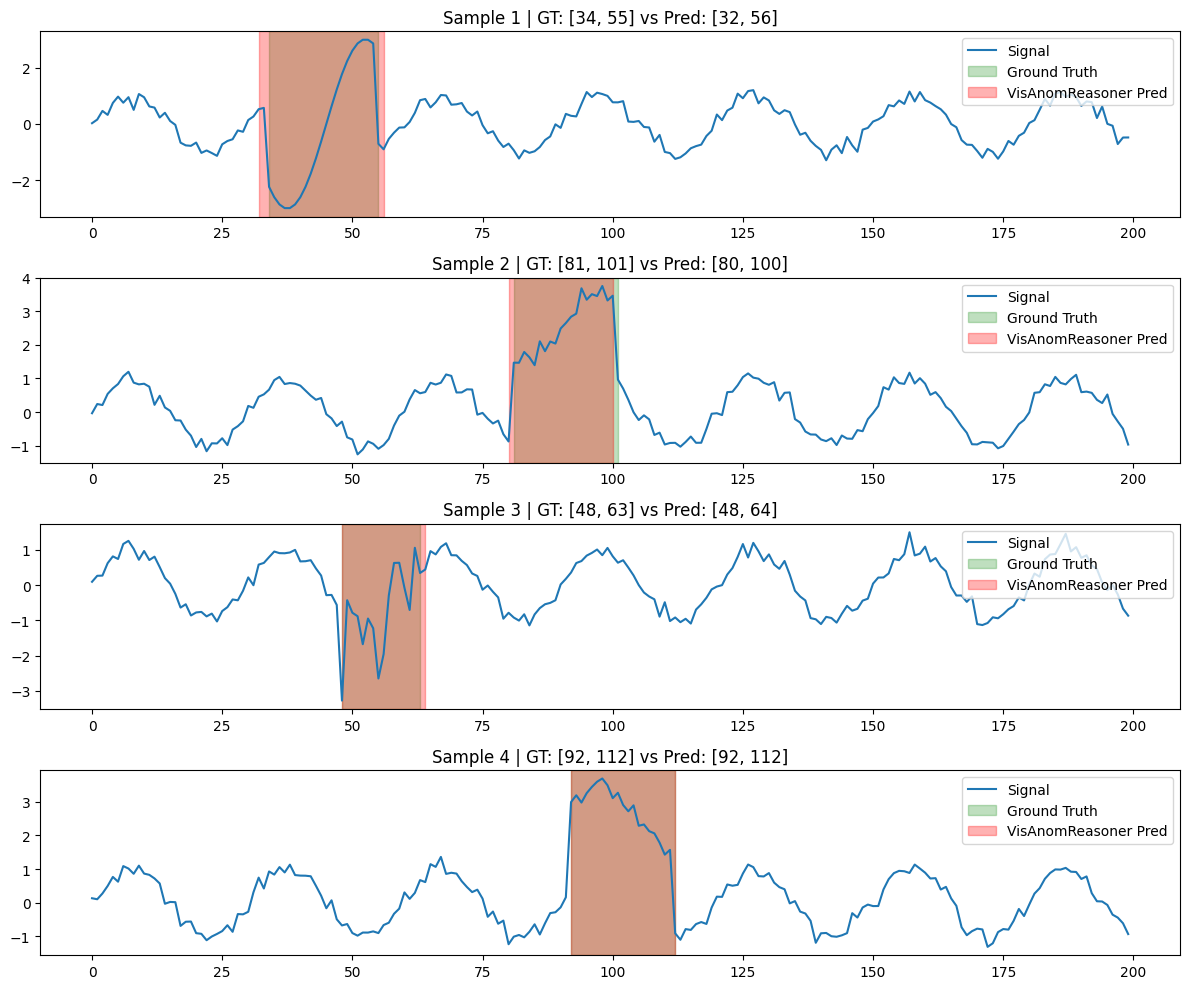

In [23]:
# [CELL 7 - Qualitative Inspection]
import matplotlib.pyplot as plt

model.eval()
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

with torch.no_grad():
    for i in range(4):
        sample = test_dataset[i]
        img = sample["image"].unsqueeze(0).to(device)
        sig = sample["signal"].numpy()
        gt_s, gt_e = sample["raw_bounds"]

        logits = model(img)
        prob = torch.sigmoid(logits)
        pred_bound = extract_bounds_from_heatmap(prob).cpu().numpy()[0]
        pr_s, pr_e = int(pred_bound[0] * 200), int(pred_bound[1] * 200)

        ax = axes[i]
        ax.plot(sig, label="Signal", color="#1f77b4")
        ax.axvspan(gt_s, gt_e, color="green", alpha=0.25, label="Ground Truth")
        ax.axvspan(pr_s, pr_e, color="red", alpha=0.3, label="VisAnomReasoner Pred")
        ax.set_title(f"Sample {i+1} | GT: [{gt_s}, {gt_e}] vs Pred: [{pr_s}, {pr_e}]")
        ax.legend(loc="upper right")

plt.tight_layout()
plt.show()